<a href="https://colab.research.google.com/github/marcossouza007/Ciencia_de_Dados/blob/main/Saude_Mental_Adolescentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Previsão da saúde mental em adolescentes: múltiplos modelos de aprendizado de máquina

Previsão da saúde mental em adolescentes: múltiplos modelos de aprendizado de máquina

Este projeto explora um tema relevante e sensível: a previsão da saúde mental de adolescentes, com foco em identificar possíveis casos de depressão com base em hábitos diários.

O conjunto de dados inclui variáveis como tempo de uso de telas, plataformas de redes sociais utilizadas (TikTok, Instagram ou ambas), horas de sono e nível de interação social.

O Desafio Principal

Durante a análise exploratória, foi identificado um problema comum em cenários reais: o desbalanceamento extremo dos dados. Em aproximadamente 1200 registros, apenas cerca de 31 pertencem à classe de interesse (depressão).

Esse tipo de distribuição pode levar modelos tradicionais a apresentarem métricas enganosas. Por exemplo, um modelo pode atingir mais de 97% de acurácia simplesmente prevendo sempre “sem depressão”, sem de fato aprender padrões relevantes.

Objetivo do Projeto

O foco deste trabalho não é maximizar uma métrica superficial, mas construir um modelo confiável, capaz de identificar corretamente a classe minoritária.

Por isso, a avaliação dos modelos prioriza métricas mais adequadas para esse cenário, como Recall e F1-Score, em vez de apenas acurácia.

Metodologia

A abordagem adotada segue boas práticas de ciência de dados, com atenção especial à prevenção de vieses e vazamento de dados:

Divisão Estratificada dos Dados
Foi utilizado o parâmetro stratify para garantir que os poucos casos de depressão fossem distribuídos de forma proporcional entre os conjuntos de treino e teste.
Tratamento do Desbalanceamento com SMOTE
Aplicação da técnica SMOTE para geração de dados sintéticos da classe minoritária.
Importante: o SMOTE foi aplicado exclusivamente no conjunto de treino, evitando vazamento de informação para o conjunto de teste.

Modelagem e Avaliação
Foram testados diferentes modelos:

Árvore de Decisão (baseline)
Random Forest
XGBoost

Modelos mais robustos foram utilizados para capturar padrões complexos e reduzir o risco de overfitting.

Considerações

Este projeto busca simular um cenário real de análise de dados, onde desafios como desbalanceamento são frequentes e exigem abordagens mais criteriosas.

Sugestões de melhoria, críticas construtivas e contribuições são bem-vindas. Caso o projeto seja útil, considere apoiar com uma estrela no repositório.






In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,recall_score,precision_score,confusion_matrix,f1_score,ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from scipy.stats import zscore
from imblearn.over_sampling import SMOTE,BorderlineSMOTE,ADASYN
from sklearn.model_selection import GridSearchCV

In [ ]:
# Caminho real do arquivo no Google Drive.
df = pd.read_csv('/content/gdrive/MyDrive/Teen_Mental_Health_Dataset.csv')

In [ ]:
display(df.head(7))

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0


In [ ]:
print('Tamanho do conjunto de dados:', df.shape)
print('Maior quantidade de valores nulos nos dados:', df.isnull().sum().max())

Tamanho do conjunto de dados: (1200, 13)
Maior quantidade de valores nulos nos dados: 0


In [ ]:
df.dtypes

,0
age,int64
gender,object
daily_social_media_hours,float64
platform_usage,object
sleep_hours,float64
screen_time_before_sleep,float64
academic_performance,float64
physical_activity,float64
social_interaction_level,object
stress_level,int64


In [ ]:
rotulo = 'depression_label'
print('Distribuição das classes:')
distribuicao = df[rotulo].value_counts()
print(f"0: {distribuicao.get(0, 0)} ocorrências (não depressão)")
print(f"1: {distribuicao.get(1, 0)} ocorrências (depressão)")

Distribuição das classes:
0: 1169 ocorrências (não depressão)
1: 31 ocorrências (depressão)


In [ ]:
print(df['social_interaction_level'].unique())
print(df['platform_usage'].unique())

['low' 'high' 'medium']
['Instagram' 'TikTok' 'Both']


Pré-processamento
Preencher valores ausentes (se houver)
Converter dados categóricos (texto) em números

In [12]:
df['gender'] = df['gender'].astype(str).str.lower().str.strip().map({'male': 1, 'female': 0}).fillna(-1)
df['social_interaction_level'] = df['social_interaction_level'].astype(str).str.lower().str.strip().map({'low': 0, 'high': 1, 'medium': 2}).fillna(-1)
df['platform_usage'] = df['platform_usage'].astype(str).str.lower().str.strip().map({'instagram': 0, 'tiktok': 1, 'both': 2}).fillna(-1)

# Check for nulls after preprocessing
print(f"{df.isnull().sum().max()} , if {df.isnull().sum().max()} there is no null")


0 , if 0 there is no null


In [11]:
Feature=df.drop(rotulo,axis=1)
Label=df[rotulo]
print('The DataSize: ', len(Label))

The DataSize:  1200


Dividir os dados em treino e teste
Selecionar o tamanho do conjunto de treino
Selecionar o tamanho do conjunto de teste

In [ ]:
x_treino, x_teste, y_treino, y_teste = train_test_split(
    Feature, Label,
    test_size=0.2,
    # train_size=500,
    random_state=42,
    stratify=Label
)

print('Tamanho do conjunto de treino:', len(y_treino))
print('Tamanho do conjunto de teste:', len(y_teste))
print('\nContagem dos rótulos no conjunto de teste:')
print(y_teste.value_counts())

Tamanho do conjunto de treino: 960
Tamanho do conjunto de teste: 240

Contagem dos rótulos no conjunto de teste:
depression_label
0    234
1      6
Name: count, dtype: int64


Tratamento do desbalanceamento no conjunto de treino com SMOTE

In [ ]:
print('Tamanho do conjunto de treino antes do SMOTE: ', len(y_treino))

#==================================================================== """

smote = SMOTE(random_state=42, k_neighbors=2)
# smote = BorderlineSMOTE(random_state=42, k_neighbors=2)
# smote = ADASYN(random_state=42,n_neighbors=2)
xtrainsmote,ytrainsmote=smote.fit_resample(x_treino,y_treino)

#==================================================================== """

print('Tamanho do conjunto de treino após o SMOTE: ', len(ytrainsmote))

Tamanho do conjunto de treino antes do SMOTE:  960
Tamanho do conjunto de treino após o SMOTE:  1870


Classificador de Árvore de Decisão
Treinamento do modelo utilizando dados balanceados com SMOTE
Realizar as previsões
Verificar as métricas de desempenho
Exibir a matriz de confusão
Exibir a importância das variáveis
Exibir a árvore de decisão

Tempo de execução: 0.05 segundos


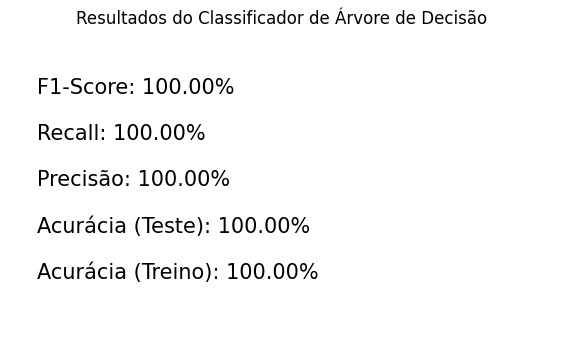

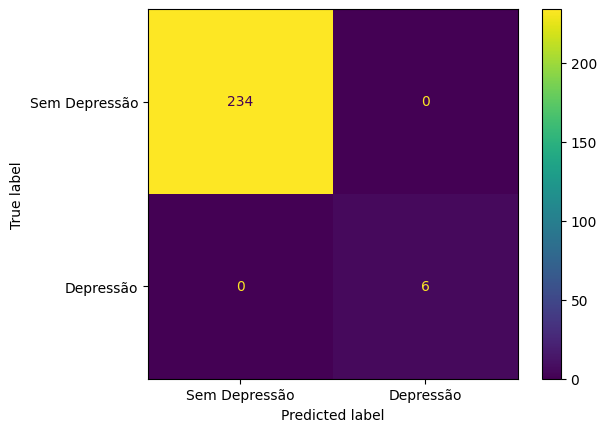

In [ ]:
starttime = time.perf_counter()

modelo_arvore = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

# Treinamento usando dados balanceados com SMOTE
modelo_arvore.fit(xtrainsmote, ytrainsmote)

# Previsões
previsoes_treino = modelo_arvore.predict(xtrainsmote)
previsoes_teste = modelo_arvore.predict(x_teste)

# Métricas
acuracia_treino = accuracy_score(ytrainsmote, previsoes_treino)
acuracia_teste = accuracy_score(y_teste, previsoes_teste)

recall = recall_score(y_teste, previsoes_teste)
precisao = precision_score(y_teste, previsoes_teste)
f1 = f1_score(y_teste, previsoes_teste)

matriz_confusao = confusion_matrix(y_teste, previsoes_teste)

print('Tempo de execução:', format(time.perf_counter() - starttime, '.2f'), 'segundos')

# Exibição dos resultados
plt.figure(figsize=(7, 4))
plt.axis('off')
plt.title('Resultados do Classificador de Árvore de Decisão')

plt.text(0.05, 0.80, f"F1-Score: {f1 * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.65, f"Recall: {recall * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.50, f"Precisão: {precisao * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.35, f"Acurácia (Teste): {acuracia_teste * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.20, f"Acurácia (Treino): {acuracia_treino * 100:.2f}%", fontsize=15, ha='left')

plt.show()

# Matriz de confusão
ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao,
    display_labels=["Sem Depressão", "Depressão"]
).plot()

plt.show()

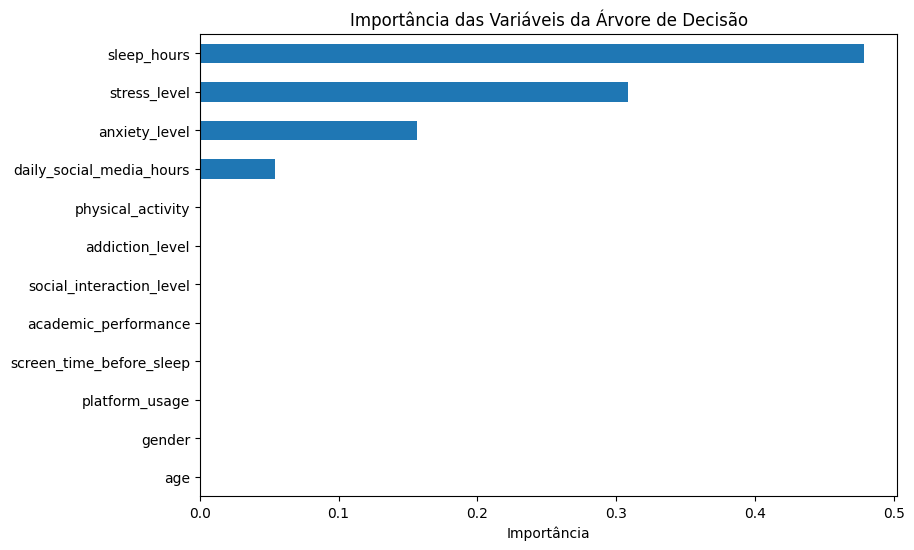

In [ ]:
pd.Series(modelo_arvore.feature_importances_, index=xtrainsmote.columns).sort_values().plot.barh(
    figsize=(9,6), title='Importância das Variáveis da Árvore de Decisão', xlabel='Importância'
)
plt.show()

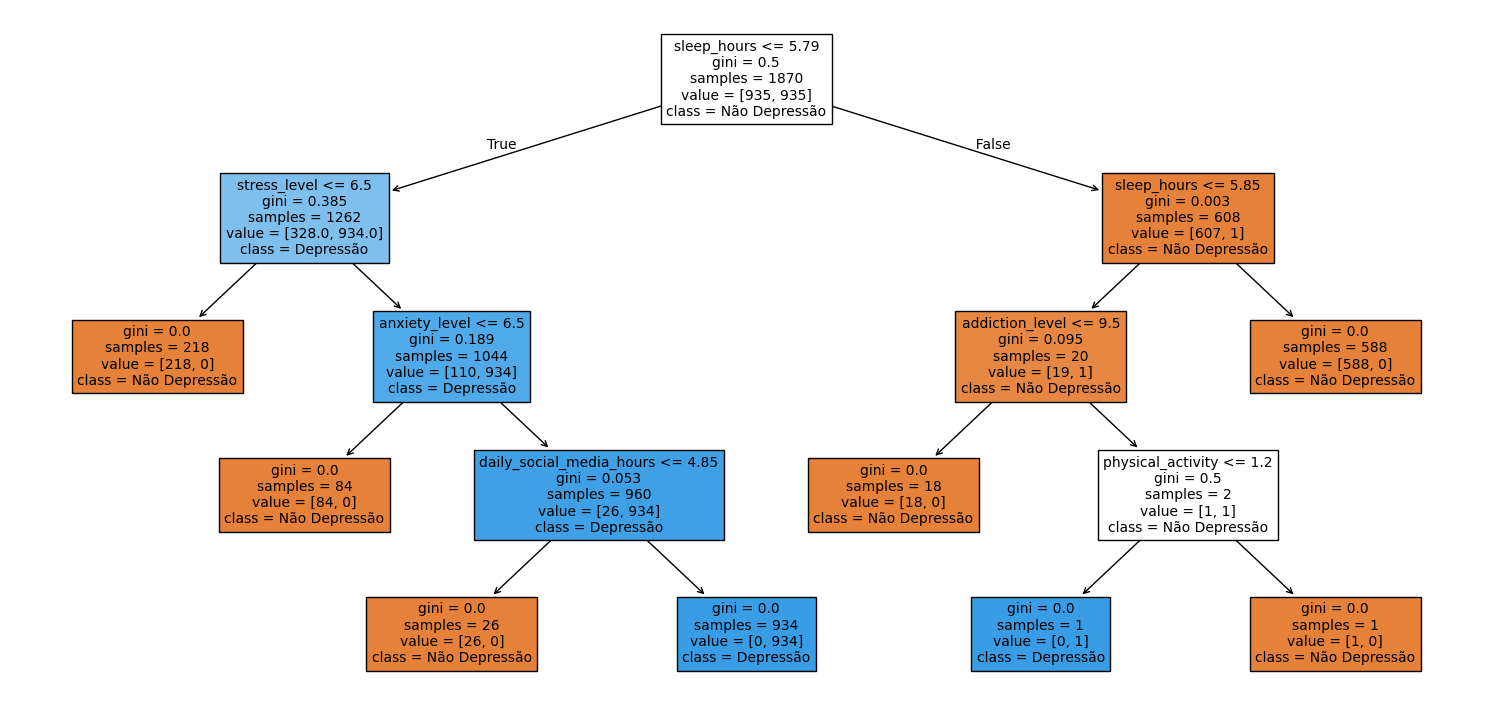

In [ ]:
plt.figure(figsize=(19, 9))
plot_tree(modelo_arvore,
          max_depth=5,
          feature_names=xtrainsmote.columns,
          class_names=["Não Depressão", "Depressão"],
          filled=True,
          rounded=False,
          fontsize=10)
plt.show()

In [ ]:
"""
------------------------


----------------------------


------------------------

"""

'\n------------------------\n\n\n----------------------------\n\n\n------------------------\n\n'

Modelo Classificador XGBoost (XGB)
Treinamento do modelo
Realizar as previsões
Verificar as métricas de desempenho
Exibir a matriz de confusão
Exibir a importância das variáveis

Tempo de execução: 0.31  segundos


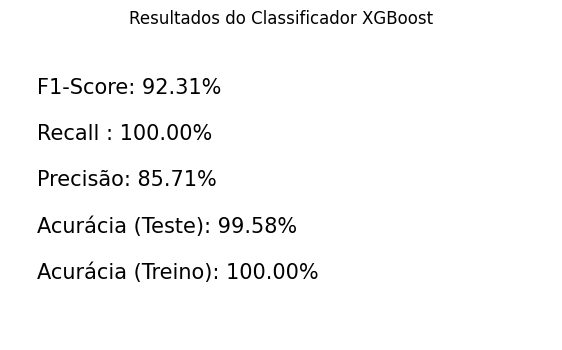

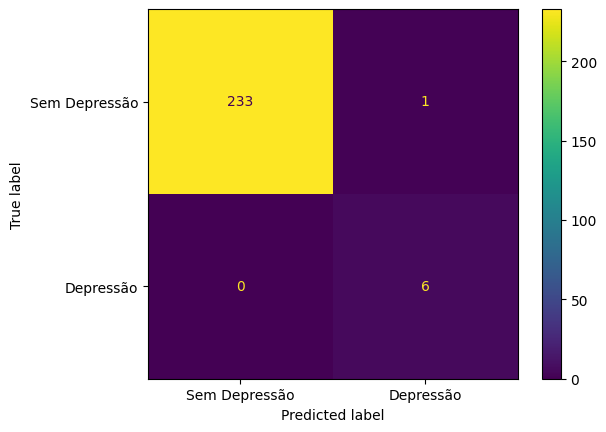

In [ ]:
starttime=time.perf_counter()

Best_Grid_Params= {'n_estimators': 500, 'learning_rate': 0.01, 'max_depth': 10,'gamma':0.1}

modelX = XGBClassifier(
    **Best_Grid_Params,
    n_jobs=-1,
    random_state=42
)
""" ==================
"""

modelX.fit(xtrainsmote,ytrainsmote)


train_predictions = modelX.predict(xtrainsmote)
test_predictions =modelX.predict(x_teste)


train_Accuracy = accuracy_score(ytrainsmote, train_predictions)
test_Accuracy = accuracy_score(y_teste, test_predictions)

Recall = recall_score(y_teste, test_predictions)
Precision = precision_score(y_teste, test_predictions)
F11 = f1_score(y_teste, test_predictions)
cm = confusion_matrix(y_teste, test_predictions)


print('Tempo de execução:',format(time.perf_counter()-starttime,'.2f'),' segundos')


plt.figure(figsize=(7,4))
plt.axis('off')
plt.title('Resultados do Classificador XGBoost')
plt.text(0.05, 0.80, f"F1-Score: {F11 * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.65, f"Recall : {Recall * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.50, f"Precisão: {Precision * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.35, f"Acurácia (Teste): {test_Accuracy * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.20, f"Acurácia (Treino): {train_Accuracy * 100:.2f}%", fontsize=15, ha='left')
plt.show()
# 82.23,,,,82.29

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Sem Depressão", "Depressão"]
).plot()

plt.show()

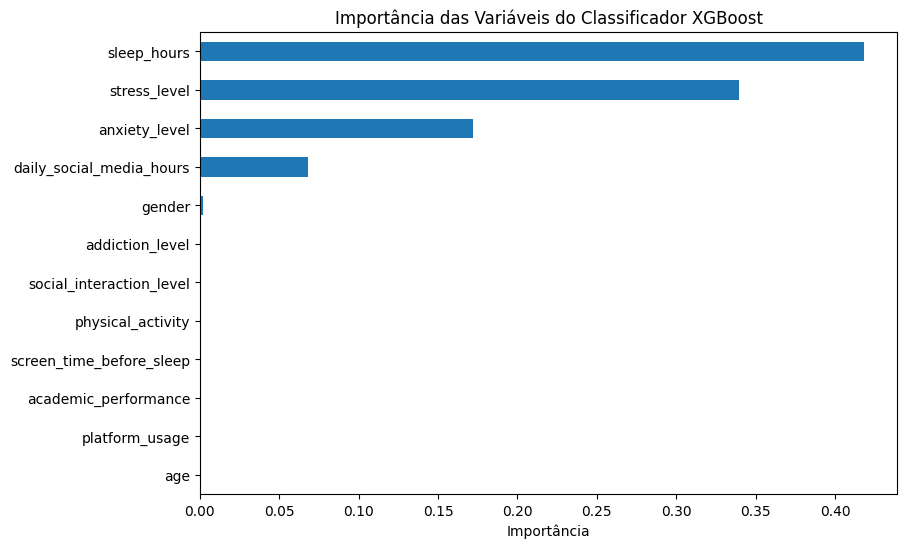

In [ ]:
pd.Series(modelX.feature_importances_, index=xtrainsmote.columns).sort_values().plot.barh(
    figsize=(9,6), title='Importância das Variáveis do Classificador XGBoost', xlabel='Importância'
)
plt.show()

### Análise de Erro

In [ ]:
identificador_erros = (y_teste == 0) & (previsoes_teste == 1)

print('Indices dos Falsos Positivos:')
indices_falsos_positivos = y_teste[identificador_erros].index
print(indices_falsos_positivos)

print('\nCaracterísticas do Falso Positivo:')
display(x_teste.loc[indices_falsos_positivos])

print('\nValores reais (y_teste) para os falsos positivos:')
display(y_teste.loc[indices_falsos_positivos])

print('\nValores previstos (previsoes_teste) para os falsos positivos:')
display(pd.Series(previsoes_teste[identificador_erros], index=indices_falsos_positivos))


Indices dos Falsos Positivos:
Index([513], dtype='int64')

Características do Falso Positivo:


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level
513,17,1,4.7,1,5.1,2.0,2.35,1.8,0,8,9,1



Valores reais (y_teste) para os falsos positivos:


,depression_label
513,0



Valores previstos (previsoes_teste) para os falsos positivos:


,0
513,1


A análise acima mostra as características do(s) adolescente(s) que o modelo classificou incorretamente como tendo depressão (Falso Positivo). Ao examinar esses dados, podemos procurar por padrões ou características incomuns que podem ter levado o modelo a fazer uma previsão errada.

Neste caso, há apenas um falso positivo. Podemos ver as características dele e tentar inferir o motivo da classificação errada. Por exemplo, se ele tiver altos níveis de estresse, ansiedade e tempo de tela, o modelo pode ter interpretado isso como depressão, mesmo que o rótulo real seja 'não depressão'.

Modelo de Classificação utilizando XGB

In [ ]:
# Grade de hiperparâmetros para busca
grade_parametros = {
    'max_depth': [5, 8, 11],
    'learning_rate': [0.01, 0.05, 0.1, 0.03],
    'n_estimators': [100, 200, 300, 500],
    # 'scale_pos_weight': [1, 3, 5]  # útil para dados desbalanceados
}

# Grade alternativa de parâmetros
parametros_alternativos = {
    "max_depth": [9, 10, 11, 12, 13],
    "learning_rate": [0.05, 0.06, 0.07, 0.08, 0.09],
    "n_estimators": [80, 100, 120, 150]
}

# Configuração do Grid Search
busca = GridSearchCV(
    XGBClassifier(random_state=42, n_jobs=1),
    param_grid=grade_parametros,
    scoring='f1_macro',
    cv=5,
    n_jobs=1
)

# Remova o comentário para executar a busca
# busca.fit(xtrain, ytrain)
# print(f"Melhor score: {busca.best_score_}")
# print(f"Melhores parâmetros: {busca.best_params_}")

Modelo Classificador Random Forest
 Treinamento do modelo com dados balanceados (SMOTE)
 Realização das previsões
 Avaliação das métricas de desempenho
 Exibição da matriz de confusão
 Exibição da importância das variáveis

Tempo de execução: 0.35 segundos


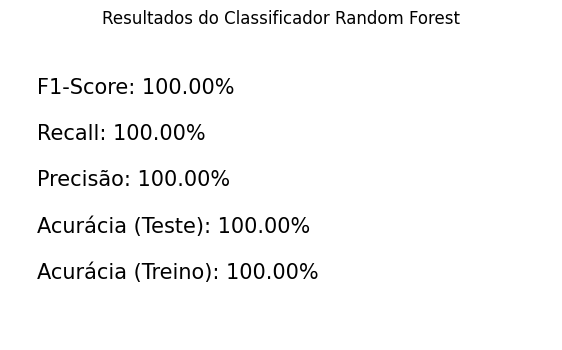

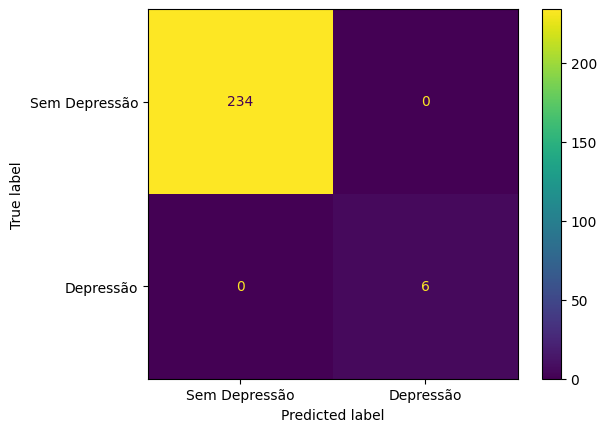

In [ ]:
starttime = time.perf_counter()

modelo_rf = RandomForestClassifier(
    max_depth=4,
    n_jobs=-1,
    n_estimators=90,  # 100
    max_features='sqrt',
    random_state=42
)

"""
 -------------------------
"""

# Treinamento usando dados balanceados com SMOTE
modelo_rf.fit(xtrainsmote, ytrainsmote)

# Previsões
previsoes_treino = modelo_rf.predict(xtrainsmote)
previsoes_teste = modelo_rf.predict(x_teste)

# Métricas
acuracia_treino = accuracy_score(ytrainsmote, previsoes_treino)
acuracia_teste = accuracy_score(y_teste, previsoes_teste)

recall = recall_score(y_teste, previsoes_teste)
precisao = precision_score(y_teste, previsoes_teste)
f1 = f1_score(y_teste, previsoes_teste)

matriz_confusao = confusion_matrix(y_teste, previsoes_teste)

print('Tempo de execução:', format(time.perf_counter() - starttime, '.2f'), 'segundos')

# Exibir os resultados
plt.figure(figsize=(7, 4))
plt.axis('off')
plt.title('Resultados do Classificador Random Forest')

plt.text(0.05, 0.80, f"F1-Score: {f1 * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.65, f"Recall: {recall * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.50, f"Precisão: {precisao * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.35, f"Acurácia (Teste): {acuracia_teste * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.20, f"Acurácia (Treino): {acuracia_treino * 100:.2f}%", fontsize=15, ha='left')

plt.show()

# Matriz de confusão
ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao,
    display_labels=["Sem Depressão", "Depressão"]
).plot()

plt.show()

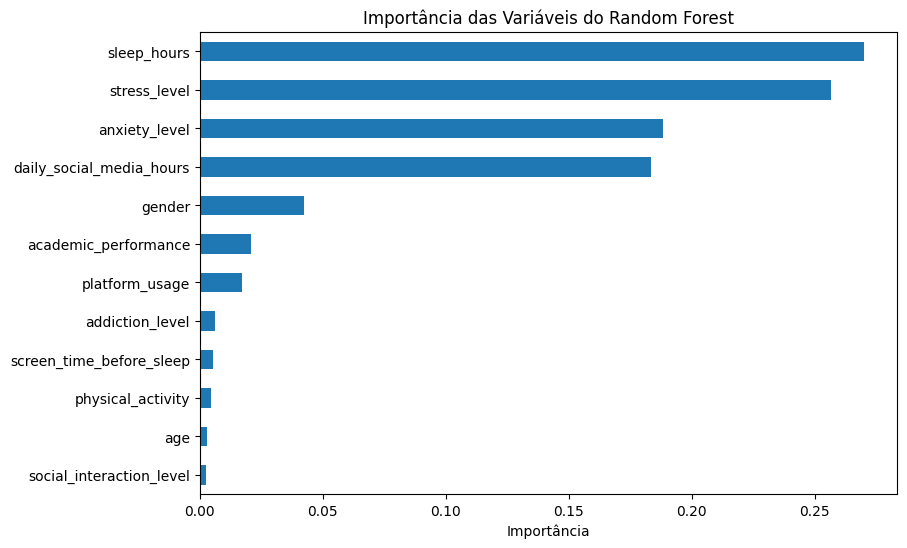

In [ ]:
pd.Series(modelo_rf.feature_importances_, index=xtrainsmote.columns).sort_values().plot.barh(
    figsize=(9,6), title='Importância das Variáveis do Random Forest', xlabel='Importância'
)
plt.show()

## 🔍 Avaliação Comparativa de Modelos
Comparação baseada em Precision, Recall e F1-score.

In [9]:

# CÉLULA AUTOSSUFICIENTE: Reconstrói todo o pipeline se necessário


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, recall_score,
    precision_score, f1_score, confusion_matrix
)
from imblearn.over_sampling import SMOTE
from google.colab import drive

# ── 1. Carrega dados ──────────────────────────────────────────
try:
    xtrainsmote
except NameError:
    print("Runtime resetado. Reconstruindo pipeline completo!\n")

    # Monta o Google Drive
    drive.mount('/content/gdrive')

    # Carrega CSV do Google Drive
    df = pd.read_csv('/content/gdrive/MyDrive/Teen_Mental_Health_Dataset.csv')

    # ── 2. Pré-processamento ──────────────────────────────────
    df['gender'] = (
        df['gender'].astype(str).str.lower().str.strip()
        .map({'male': 1, 'female': 0}).fillna(-1)
    )
    df['social_interaction_level'] = (
        df['social_interaction_level'].astype(str).str.lower().str.strip()
        .map({'low': 0, 'high': 1, 'medium': 2}).fillna(-1)
    )
    df['platform_usage'] = (
        df['platform_usage'].astype(str).str.lower().str.strip()
        .map({'instagram': 0, 'tiktok': 1, 'both': 2}).fillna(-1)
    )

    rotulo  = 'depression_label'
    Feature = df.drop(rotulo, axis=1)
    Label   = df[rotulo]

    # ── 3. Divisão treino/teste ───────────────────────────────
    x_treino, x_teste, y_treino, y_teste = train_test_split(
        Feature, Label,
        test_size=0.2,
        random_state=42,
        stratify=Label
    )

    # ── 4. SMOTE (somente no treino) ──────────────────────────
    smote = SMOTE(random_state=42, k_neighbors=2)
    xtrainsmote, ytrainsmote = smote.fit_resample(x_treino, y_treino)

    # ── 5. Treina os três modelos ─────────────────────────────
    modelo_arvore = DecisionTreeClassifier(max_depth=10, random_state=42)
    modelo_arvore.fit(xtrainsmote, ytrainsmote)

    modelX = XGBClassifier(
        n_estimators=500, learning_rate=0.01,
        max_depth=10, gamma=0.1,
        n_jobs=-1, random_state=42
    )
    modelX.fit(xtrainsmote, ytrainsmote)

    modelo_rf = RandomForestClassifier(
        max_depth=4, n_estimators=90,
        max_features='sqrt', n_jobs=-1, random_state=42
    )
    modelo_rf.fit(xtrainsmote, ytrainsmote)

    print("Pipeline reconstruído com sucesso!\n")

# ── 6. Avaliação Comparativa ──────────────────────────────────
models = {
    "Random Forest": modelo_rf,
    "Decision Tree": modelo_arvore,
    "XGBoost":       modelX
}

results = []

for name, model in models.items():
    y_pred = model.predict(x_teste)
    print(f"\nModelo: {name}")
    print(classification_report(y_teste, y_pred, zero_division=0))

    report   = classification_report(y_teste, y_pred, output_dict=True, zero_division=0)
    class_key = '1' if '1' in report else 1

    results.append({
        "Modelo":   name,
        "Precision": report.get(class_key, {}).get('precision', 0.0),
        "Recall":    report.get(class_key, {}).get('recall',    0.0),
        "F1-score":  report.get(class_key, {}).get('f1-score',  0.0)
    })

results_df = pd.DataFrame(results)
results_df

Runtime resetado. Reconstruindo pipeline completo!

Mounted at /content/gdrive
Pipeline reconstruído com sucesso!


Modelo: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00         6

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240


Modelo: Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       1.00      1.00      1.00         6

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240


Modelo: XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       0.86      1.00      0.92         6

    

,Modelo,Precision,Recall,F1-score
0,Random Forest,1.000000,1.0,1.000000
1,Decision Tree,1.000000,1.0,1.000000
2,XGBoost,0.857143,1.0,0.923077


##  Importância das Variáveis

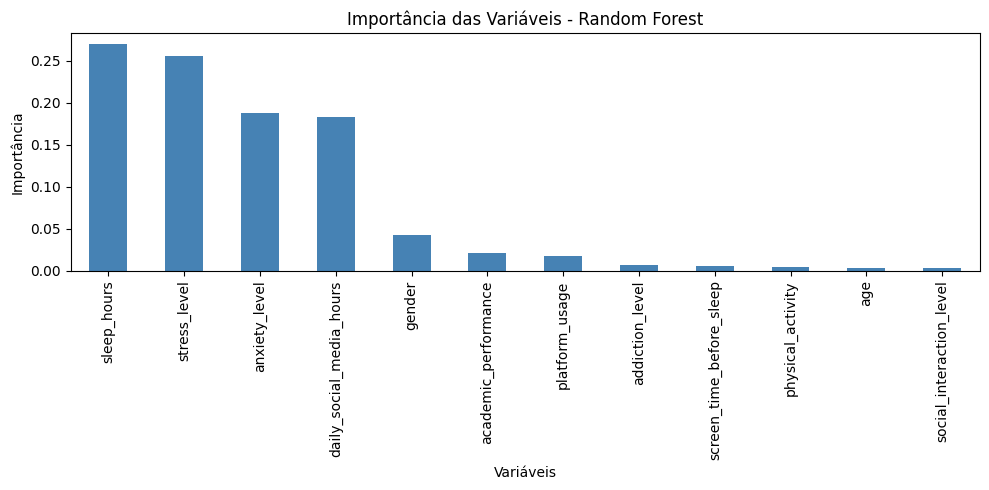

In [10]:
# Importância das Variáveis (depende da célula anterior ter rodado)
import matplotlib.pyplot as plt
import pandas as pd

feat_imp = pd.Series(
    modelo_rf.feature_importances_,
    index=xtrainsmote.columns
).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.title("Importância das Variáveis - Random Forest")
plt.ylabel("Importância")
plt.xlabel("Variáveis")
plt.tight_layout()
plt.show()


**negrito**
##  Interpretação dos Resultados

Variáveis como uso de redes sociais e sono têm alto impacto na previsão.

##  Limitações

O modelo não considera fatores externos importantes e não deve ser usado como diagnóstico.


 **Conclusão**



O objetivo deste projeto foi analisar se existe relação entre o uso de redes sociais e possíveis sinais de impacto na saúde mental de adolescentes, utilizando modelos de machine learning para prever risco de depressão a partir de dados comportamentais.

Durante os testes, foi possível observar que modelos como Random Forest e XGBoost apresentaram resultados mais consistentes em comparação com Decision Tree, principalmente quando analisado o equilíbrio entre precisão e recall. Considerando o contexto do problema, o recall se mostrou uma métrica importante, já que reduzir falsos negativos é essencial quando se trata de identificar possíveis casos de risco.

Na análise das variáveis, fatores como tempo de uso de redes sociais, qualidade do sono e nível de atividade física tiveram maior influência nas previsões do modelo. Esses pontos fazem sentido do ponto de vista comportamental e ajudam a dar mais confiança na análise, mesmo sendo um estudo exploratório.

Por outro lado, o projeto também apresenta limitações. Os dados utilizados não consideram fatores importantes como contexto familiar, condição socioeconômica ou acompanhamento psicológico, o que pode impactar diretamente nos resultados. Além disso, o modelo identifica padrões, mas não permite afirmar relação de causa e efeito.

Outro ponto importante é que esse tipo de solução não deve ser usado como diagnóstico. O modelo pode servir como apoio para análise ou triagem inicial, mas qualquer decisão real precisa envolver profissionais da área.

De forma geral, o projeto mostra como técnicas de machine learning podem ajudar a identificar padrões relevantes em dados comportamentais, mas também reforça a importância de interpretar os resultados com cuidado, principalmente em temas sensíveis como saúde mental.